# Prevendo Analfabetismo nos Municípios Brasileiros

O INEP (Instituto Nacional de Pesquisas Educacionais Anísio Teixeira) tem como meta para 2030 reduzir o analfabetismo para X%.

Para isso consultamos as bases do SAEB (Sistema de Avaliação da Educação Básica) que tem a nota de Proficiência dos alunos. Se o aluno ficar acima de 743 pontos é considerado Alfabetizado.

O objetivo deste trabalho é construir um modelo que, baseado nas informações socioeconômicas dos municípios, prevê a nota média do SAEB dos seus alunos.

Para isso começamos enumerando hipóteses para o analfabetismo:
* Renda média: será que em municípios mais ricos (mesmo com desigualdade) as crianças performam melhor?
* Alfabetização dos pais: será que ambientes com mais letramento dos adultos influenciam positivamente?
* Investimento em educação: será que municípios que investem mais obtêm mais "retorno" em literácia e, indiretamente, em produtividade e no próprio PIB?
* Dificuldade de acesso: será que municípios com poucas escolas (proporcionalmente à população) ou muito espalhados (poucas escolas por km2) tem mais dificuldade para alfabetizar suas crianças?
* Região Metropolitana: será que municípios do "interior" alfabetizam menos?

Com isso cruzamos variáveis de diversos âmbitos, desde o educacional (qtd escolas, qtd alunos) com variáveis sociais (alfabetização dos adultos e idosos) e econômicas (PIB per capita, investimeno em educação)

O primeiro passo é reunir todos os dados, e segundo a arquitetura Medallion, teremos os seguintes repositórios:
* Bronze
  - recebe as tabelas "cruas" do jeito que vierem das fontes
  - Se a fonte for API ou BigQuery/Redshift, os dados virão diretamente da fonte através do pipeline
  - No nosso caso usamos tabelas baixadas manualmente dos sites do governo, com algum tratamento manual (correção de nomes de municípios, etc) então a Bronze receberá esses resultados iniciais e, em caso de refação da etapa manual, a tabela é substituída
* Silver
  - recebe os dados já cruzados das diversas origens. É a Fonte Única de Verdade (SSoT) usada para os modelos e dashboards na camada Gold
  - cruzamentos de tabelas, remoção de duplicidades, tratamento de valores nulos: tudo isso acontece aqui
* Gold
  - tabelas prontas para cada dashboard ou modelo diferente
  - Nem todo modelo usa todas as variáveis disponíveis
  - Dashboards em geral usam agregações dos dados, às vezes pré-filtrados
  - A tabela gold resolve essas agregações, filtros e projeções

# Obtendo dados: renda média dos municípios

Utilizamos a base de dados do IBGE ([PNAD Contínua](https://www.kaggle.com/datasets/kira_fintech/ibge-pnad-contnua-2016-2024-microdata-parquet)).

* A base apresenta informações de rendimento médio com diversas segmentações (homens e mulheres, população ocupada, desocupada e fora da força de trabalho). Para este trabalho foi utilizado apenas o **rendimento médio total**.
* A coluna de **mediana** foi desconsiderada, pois seus valores já se encontravam previamente arredondados em centenas de reais, introduzindo uma camada adicional de imprecisão sobre um dado que já possui variabilidade inerente ao processo de coleta por entrevistas amostrais.
* Foram tratados manualmente alguns casos de nomenclatura fora do padrão. A base reúne determinadas aglomerações urbanas, como **Petrolina (PE) / Juazeiro (BA)**, **Macaé / Rio das Ostras (RJ)**, **Volta Redonda / Barra Mansa (RJ)**, **Caraguatatuba / Ubatuba / São Sebastião (SP)**, entre outras. Nesses casos, o mesmo valor de rendimento médio foi atribuído a todos os municípios envolvidos.
* Ao final, foram mantidos apenas os seguintes campos:

  * Nome do município;
  * Rendimento médio (total).

A base resultante contém **201 municípios**, representando aproximadamente **100 milhões de habitantes**, cerca de **46% da população brasileira**.

## Obtenção da base de latitude e longitude

Utilizamos a base de coordenadas geográficas do [Gov.br](https://www.gov.br/portos-e-aeroportos/pt-br/assuntos/transporte-aereo/plano-aeroviario-nacional/apendice_vii__dados_de_municipios_e_utp_pan24.xlsx/@@download/file).

* Inicialmente foi realizada a padronização dos nomes dos municípios para compatibilização com a base da PNAD, corrigindo manualmente os poucos casos divergentes.
* Em seguida, foram mantidos apenas os campos necessários para o projeto:

  * Código IBGE do município;
  * Nome;
  * UF;
  * Latitude;
  * Longitude;
  * Indicador de capital ou não;
  * Quantidade de viagens OD 2017 (utilizada como proxy de porte/relevância do município em casos de ambiguidade).
* O objetivo desta etapa é possibilitar o cruzamento entre as duas bases, consolidando em um único conjunto as informações de localização geográfica e rendimento médio.

## Estimativa da renda média dos demais municípios

Como a base PNAD contempla apenas as principais cidades brasileiras, estas foram consideradas como **Cidades-Pai**, servindo como referência para estimar a renda média dos demais municípios.

Após a consolidação das bases, cada registro passou a conter os seguintes campos:

* Código IBGE;
* Nome;
* UF;
* Latitude;
* Longitude;
* Indicador de capital;
* Quantidade de viagens OD 2017;
* Rendimento médio;
* Indicador de Cidade-Pai (`flag_pai`).

Para cada município que não pertence ao conjunto de Cidades-Pai foi calculada a distância até todas as Cidades-Pai utilizando a **distância de Haversine**, que representa a menor distância entre dois pontos sobre a superfície terrestre considerando a curvatura da Terra.

Cada município foi então associado à Cidade-Pai mais próxima. Aqui foi usado o algoritmo de Nearest Neighbors, da biblioteca `sklearn`.

Por fim, a renda média dos municípios não pertencentes à base PNAD foi estimada a partir da renda da respectiva Cidade-Pai, aplicando-se um redutor composto por:

* **5% de redução fixa**;
* **mais 1% para cada 100 km** de distância em relação à Cidade-Pai.

Assim, por exemplo:

* até **100 km**: renda estimada **5% inferior** à da Cidade-Pai;
* de **101 a 200 km**: **6% inferior**;
* de **201 a 300 km**: **7% inferior**, e assim sucessivamente.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/municipios.csv', sep=';')
df.rename(columns={'renda média': 'renda_media', 'cidade pai': 'cidade_pai'}, inplace=True)
display(df.head())

,codigo_ibge,nome,uf,latitude,longitude,capital,viagens_2017,renda_media,cidade_pai,Unnamed: 9
0,3550308,São Paulo,SP,-23.567385,-46.570382,1,24900111,2768.14,1,NaN
1,3304557,Rio de Janeiro,RJ,-22.876650,-43.227873,1,13109678,2339.78,1,NaN
2,5300108,Brasília,DF,-15.794086,-47.887905,1,11826126,3072.72,1,NaN
3,2304400,Fortaleza,CE,-3.723805,-38.589927,1,7588860,1806.63,1,NaN
4,2611606,Recife,PE,-8.062761,-34.888941,1,6364814,1880.35,1,NaN


In [ ]:
pais = df[df['cidade_pai'] == 1].copy()
filhas = df[df['cidade_pai'] == 0].copy()

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

nn = NearestNeighbors(
    n_neighbors=1,
    metric="haversine",
    algorithm="ball_tree"
)

# metric = "haversine" espera radianos
coords_pais = np.radians( pais[["latitude","longitude"]] )
coords_filhas = np.radians( filhas[["latitude","longitude"]])

nn.fit(coords_pais)

distancias, indices = nn.kneighbors(coords_filhas)

distancias_km = distancias.flatten() * 6371

In [ ]:
filhas["cidade_pai_escolhida"]             = pais.iloc[ indices.flatten() ]["nome"].values
filhas["codigo_ibge_cidade_pai_escolhida"] = pais.iloc[ indices.flatten() ]["codigo_ibge"].values
filhas["renda_media_cidade_pai_escolhida"] = pais.iloc[ indices.flatten() ]["renda_media"].values

filhas["distancia_km"] = distancias_km

In [ ]:
import numpy as np

# Calculate redutor_renda
def calcular_redutor_renda(distancia):
    if distancia <= 100:
        return 0.05  # 5%
    else:
        # 5% + 1% a cada 100km adicionais
        return 0.05 + 0.01 * np.floor((distancia - 100) / 100)

filhas['redutor_renda'] = filhas['distancia_km'].apply(calcular_redutor_renda)

# Calculate renda_media_ajustada
filhas['renda_media_ajustada'] = filhas['renda_media_cidade_pai_escolhida'] * (1 - filhas['redutor_renda'])


In [ ]:
filhas.sample(5)

# # Top 10 cidades distantes de seus pais (maiores redutores de renda)
# filhas.sort_values(by='distancia_km', ascending=False).head()

,codigo_ibge,nome,uf,latitude,longitude,capital,viagens_2017,renda_media,cidade_pai,Unnamed: 9,cidade_pai_escolhida,codigo_ibge_cidade_pai_escolhida,renda_media_cidade_pai_escolhida,distancia_km,redutor_renda,renda_media_ajustada
2412,4125001,São João do Ivaí,PR,-23.993089,-51.820278,0,739,NaN,0,NaN,Apucarana,4101408,2141.98,61.272157,0.05,2034.8810
2899,3142700,Montalvânia,MG,-14.420363,-44.363618,0,440,NaN,0,NaN,Montes Claros,3143302,1846.77,261.510379,0.06,1735.9638
1453,5205307,Cavalcante,GO,-13.799277,-47.463436,0,2144,NaN,0,NaN,Formosa,5208004,1927.05,194.150355,0.05,1830.6975
3665,3138104,Lassance,MG,-17.895115,-44.579357,0,187,NaN,0,NaN,Montes Claros,3143302,1846.77,150.795569,0.05,1754.4315
3193,1508209,Vigia,PA,-0.855531,-48.141497,0,321,NaN,0,NaN,Castanhal,1502400,1323.05,54.467637,0.05,1256.8975


In [ ]:
import numpy as np

# Preparar o DataFrame 'pais'
pais_final = pais[[
    'codigo_ibge', 'nome', 'uf', 'latitude', 'longitude', 'capital', 'cidade_pai', 'renda_media'
]].copy()
pais_final['codigo_ibge_cidade_pai_escolhida'] = np.nan
pais_final['cidade_pai_escolhida'] = np.nan
pais_final['distancia_km'] = np.nan
pais_final['renda_media_cidade_pai_escolhida'] = np.nan
pais_final['redutor_renda'] = np.nan

# Preparar o DataFrame 'filhas'
filhas_final = filhas[[
    'codigo_ibge', 'nome', 'uf', 'latitude', 'longitude', 'capital', 'cidade_pai',
    'cidade_pai_escolhida', 'codigo_ibge_cidade_pai_escolhida',
    'distancia_km', 'renda_media_cidade_pai_escolhida', 'redutor_renda', 'renda_media_ajustada'
]].copy()
filhas_final['renda_media'] = filhas_final['renda_media_ajustada']

# Selecionar e ordenar as colunas para o DataFrame final
final_columns = [
    'codigo_ibge', 'nome', 'uf', 'latitude', 'longitude', 'capital', 'cidade_pai',
    'renda_media', 'cidade_pai_escolhida', 'codigo_ibge_cidade_pai_escolhida',
    'distancia_km', 'renda_media_cidade_pai_escolhida', 'redutor_renda'
]

pais_final = pais_final[final_columns]
filhas_final = filhas_final[final_columns]

# Concatenar os DataFrames
df_final = pd.concat([pais_final, filhas_final], ignore_index=True)

display(df_final.head())

,codigo_ibge,nome,uf,latitude,longitude,capital,cidade_pai,renda_media,cidade_pai_escolhida,codigo_ibge_cidade_pai_escolhida,distancia_km,renda_media_cidade_pai_escolhida,redutor_renda
0,3550308,São Paulo,SP,-23.567385,-46.570382,1,1,2768.14,NaN,NaN,NaN,NaN,NaN
1,3304557,Rio de Janeiro,RJ,-22.876650,-43.227873,1,1,2339.78,NaN,NaN,NaN,NaN,NaN
2,5300108,Brasília,DF,-15.794086,-47.887905,1,1,3072.72,NaN,NaN,NaN,NaN,NaN
3,2304400,Fortaleza,CE,-3.723805,-38.589927,1,1,1806.63,NaN,NaN,NaN,NaN,NaN
4,2611606,Recife,PE,-8.062761,-34.888941,1,1,1880.35,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_final_formatted = df_final.copy()

# Round latitude and longitude to 4 decimal places
df_final_formatted['latitude'] = df_final_formatted['latitude'].round(4)
df_final_formatted['longitude'] = df_final_formatted['longitude'].round(4)

# Round other numeric columns to 2 decimal places
numeric_cols_to_round = [
    'renda_media',
    'distancia_km',
    'renda_media_cidade_pai_escolhida',
    'redutor_renda'
]

for col in numeric_cols_to_round:
    if col in df_final_formatted.columns:
        df_final_formatted[col] = df_final_formatted[col].round(2)

# Convert 'codigo_ibge_cidade_pai_escolhida' to Int64 to remove decimal places
# and handle NaN values appropriately for export to CSV
if 'codigo_ibge_cidade_pai_escolhida' in df_final_formatted.columns:
    df_final_formatted['codigo_ibge_cidade_pai_escolhida'] = df_final_formatted['codigo_ibge_cidade_pai_escolhida'].astype('Int64')

df_final_formatted.to_csv('municipios_com_renda_inferida.csv', index=False)
print('DataFrame df_final exportado para municipios_com_renda_inferida.csv com formatação de decimais.')

DataFrame df_final exportado para df_final.csv com formatação de decimais.


# Obtendo Dados: distância de cada município em relação à sua respectiva capital

Utilizamos os mesmos dados de lat-long usados anteriormente.

* A base apresenta latitude e longitude de todos os 5571 municípios brasileiros, indicando quais deles são capitais estaduais (27).
* O script abaixo separa as capitais dos demais municípios, e para cada município não-capital, calcula a distância para a capital de seu estado.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/municipios.csv', sep=';')

# Select only the requested columns
df = df[['codigo_ibge', 'nome', 'uf', 'latitude', 'longitude', 'capital']]

display(df.head())

In [ ]:
capitais = df[df['capital'] == 1].copy()
nao_cap  = df[df['capital'] == 0].copy()

In [ ]:
import numpy as np

# Prepare a DataFrame with capital information to merge
capitais_info = capitais[['uf', 'latitude', 'longitude', 'nome', 'codigo_ibge']].rename(columns={
    'latitude': 'latitude_capital',
    'longitude': 'longitude_capital',
    'nome': 'nome_capital',
    'codigo_ibge': 'codigo_ibge_capital'
})

# Merge nao_cap with capital information and assign to 'filhas'
# The 'filhas' DataFrame will now contain information about the capital for each non-capital city.
caps_e_nao_caps = nao_cap.merge(capitais_info, on='uf', how='left')

# Convert coordinates from degrees to radians for Haversine calculation
lat1_rad = np.radians(caps_e_nao_caps['latitude'])
lon1_rad = np.radians(caps_e_nao_caps['longitude'])
lat2_rad = np.radians(caps_e_nao_caps['latitude_capital'])
lon2_rad = np.radians(caps_e_nao_caps['longitude_capital'])

# Haversine formula calculation
dlon = lon2_rad - lon1_rad
dlat = lat2_rad - lat1_rad

a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

R = 6371 # Earth radius in kilometers
caps_e_nao_caps['distancia_km'] = R * c

# Drop the intermediate capital-specific coordinate and name columns
caps_e_nao_caps = caps_e_nao_caps.drop(columns=['latitude_capital', 'longitude_capital', 'nome_capital', 'codigo_ibge_capital'])

In [ ]:
df_final_formatted = caps_e_nao_caps.copy()

# Round latitude and longitude to 4 decimal places
df_final_formatted['latitude'] = df_final_formatted['latitude'].round(4)
df_final_formatted['longitude'] = df_final_formatted['longitude'].round(4)
df_final_formatted['distancia_km'] = df_final_formatted['distancia_km'].round(1)

# Convert 'codigo_ibge_cidade_pai_escolhida' to Int64 to remove decimal places
# and handle NaN values appropriately for export to CSV
if 'codigo_ibge' in df_final_formatted.columns:
    df_final_formatted['codigo_ibge'] = df_final_formatted['codigo_ibge'].astype('Int64')

df_final_formatted.to_csv('dist_km_capital.csv', index=False)
print('DataFrame df_final exportado para dist_km_capital.csv com formatação de decimais.')

# Reunindo todos os dados

Com todas as origens obtidas, é hora de subir tudo para a pipeline. Subimos os arquivos CSV obtidos para o Bigquery por importação manual, gerando 6 tabelas Bronze:
* área e população dos municípios
* renda per capita por município
* receitas e despesas com educação, por município
* alfabetização de adultos (20-64) e idosos (65+)

Juntamos com essas tabelas os dados que já possuímos de alfabetização infantil e suas respectivas metas (bases Saeb 2023/24) com o script abaixo:

In [ ]:
create or replace table `etapa2-techchallenge.silver._municipios` as
select
coalesce(ap.codigo_ibge, r.codigo_ibge, rd.codigo_ibge, dc.codigo_ibge) as codigo_ibge,        -- chave
coalesce(ap.mun,r.nome,rd.entidade,dc.nome) as nome, ap.uf as uf, r.capital as fl_capital,
r.latitude as lat, r.longitude as long,dc.distancia_km as dist_capital,                         -- dados basicos
pop, area_km2, pop_km2 as dens_pop,                             -- pop, area, densidade
renda_media as renda_media, 1-cidade_pai as fl_renda_inferida,  -- renda media
receita_contrib, compl_vaaf, compl_vaat, compl_vaar,
desp_empenhada, desp_liquidada, desp_paga
from              `etapa2-techchallenge.bronze.area_pop` ap
full outer join `etapa2-techchallenge.bronze.mun_renda_inferida`    r  on ap.codigo_ibge = r.codigo_ibge
full outer join `etapa2-techchallenge.bronze.receitas_despesas` rd on ap.codigo_ibge = rd.codigo_ibge
full outer join `etapa2-techchallenge.bronze.dist_km_capital` dc on ap.codigo_ibge = dc.codigo_ibge
where entidade not like '%governo%'
order by 1;

create or replace table `etapa2-techchallenge.silver._alfabetizacao` as
select coalesce(cast(i.id_municipio as integer), a.id_municipio) as id_municipio, -- codigo_ibge
pct_20_60_alf as alfab_adulto, pct_65_m_alf as alfab_idoso,                      -- alfabetização adultos/idosos
ano,                                                                             -- forma cartesiano (dados municipio se repetem por ano)
qtd_escolas, qtd_alunos, pct_alfabetizados as TARGET_alfab_infantil              -- alfabetização infantil
from            `etapa2-techchallenge.bronze.alfabetizao_infantil` i
full outer join `etapa2-techchallenge.bronze.alfabetizacao_adultos_idosos`   a on cast(i.id_municipio as integer) = a.id_municipio
order by 1, 4;

create or replace table `etapa2-techchallenge.bronze._meta` as
SELECT id_municipio, meta_alfabetizacao_2025
FROM `etapa2-techchallenge.bronze.meta_alfabetizacao_municipio`
where ano = 2024;

create or replace  table `etapa2-techchallenge.silver._silverfinal` as
select 	coalesce(m.codigo_ibge, a.id_municipio) as id_municipio, nome,
uf, fl_capital, lat, long, dist_capital, pop, area_km2, dens_pop, -- dados basicos
renda_media, fl_renda_inferida,                     -- renda media
receita_contrib as receita_fundeb,                                -- financiamento via Fundeb (ainda faltando)
compl_vaaf, compl_vaat, compl_vaar,                 -- complementacao da Uniao (receita)
desp_empenhada, desp_liquidada, desp_paga,          -- despesas com
ano,                                                -- 2023 treino, 2024 teste
qtd_escolas, qtd_alunos,                            -- dados demografia escolar
round(qtd_escolas * 100000 /pop,2) as qtd_escolas_100k,
t.meta_alfabetizacao_2025,
alfab_adulto, alfab_idoso, TARGET_alfab_infantil    -- alfabetizacoes por faixa
from etapa2-techchallenge.silver._municipios m
full outer join etapa2-techchallenge.silver._alfabetizacao a on m.codigo_ibge = a.id_municipio
left outer join etapa2-techchallenge.bronze._meta t on cast(m.codigo_ibge as string) = t.id_municipio
order by 1, 19


Create or replace table `etapa2-techchallenge.silver._silverfinal_semnulos` as
SELECT
IFNULL(`id_municipio`,0) as id_municipio,
IFNULL(`nome`,'0') as nome,
IFNULL(`uf`,"0") as uf,
IFNULL(`fl_capital`,0) as fl_capital,
IFNULL(`lat`,0) as lat,
IFNULL(`long`,0) as long,
IFNULL(`dist_capital`,0) as dist_capital,
IFNULL(`pop`,0) as pop,
IFNULL(`area_km2`,0) as area_km2,
IFNULL(`dens_pop`,0) as dens_pop,
IFNULL(`renda_media`,0) as renda_media,
IFNULL(`fl_renda_inferida`,0) as fl_renda_inferida,
IFNULL(`receita_fundeb`,0) as receita_fundeb,
IFNULL(`compl_vaaf`,0) as compl_vaaf,
IFNULL(`compl_vaat`,0) as compl_vaat,
IFNULL(`compl_vaar`,0) as compl_vaar,
IFNULL(`desp_empenhada`,0) as desp_empenhada,
IFNULL(`desp_liquidada`,0) as desp_liquidada,
IFNULL(`desp_paga`,0) as desp_paga,
IFNULL(`ano`,'0') as ano,
IFNULL(`qtd_escolas`,0) as qtd_escolas,
IFNULL(`qtd_alunos`,0) as qtd_alunos,
IFNULL(`qtd_escolas_100k`,0) as qtd_escolas_100k,
IFNULL(`alfab_adulto`,0) as alfab_adulto,
IFNULL(`alfab_idoso`,0) as alfab_idoso,
IFNULL(`TARGET_alfab_infantil`,0) as TARGET_alfab_infantil,
 FROM `etapa2-techchallenge.silver._silverfinal`

# Multicolinearidade e Correlações entre variáveis dos municípios

Uma vez reunidas as variáveis, começamos a investigação em busca de correlações e multicolinearidades indesejadas através de diversas metodologias como VIF, correlação Spearman e matriz de dispersão

In [ ]:
!pip install google-cloud-bigquery pandas-gbq scikit-learn

In [ ]:
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery

client = bigquery.Client(project="etapa2-techchallenge")

query = "SELECT * FROM etapa2-techchallenge.silver._silverfinal"

df = client.query(query).to_dataframe()

print(df.shape)
df.head()

(10412, 27)


,id_municipio,nome,uf,fl_capital,lat,long,dist_capital,pop,area_km2,dens_pop,...,desp_liquidada,desp_paga,ano,qtd_escolas,qtd_alunos,qtd_escolas_100k,meta_alfabetizacao_2025,alfab_adulto,alfab_idoso,TARGET_alfab_infantil
0,1100015,Alta Floresta d'Oeste,RO,0,-11.9355,-61.9998,405.1,21494,7067.127,3.04,...,5898075.79,5898075.79,2023,5,227,23.26,69.51,94.94,67.54,67.40
1,1100015,Alta Floresta d'Oeste,RO,0,-11.9355,-61.9998,405.1,21494,7067.127,3.04,...,5898075.79,5898075.79,2024,8,275,37.22,69.51,94.94,67.54,68.00
2,1100023,Ariquemes,RO,0,-9.9085,-63.0333,154.0,96833,4426.127,21.88,...,NaN,NaN,2023,22,1222,22.72,68.02,96.51,71.36,62.52
3,1100023,Ariquemes,RO,0,-9.9085,-63.0333,154.0,96833,4426.127,21.88,...,NaN,NaN,2024,18,1066,18.59,68.02,96.51,71.36,65.85
4,1100031,Cabixi,RO,0,-13.4998,-60.5443,636.6,5351,1314.352,4.07,...,NaN,NaN,2023,3,76,56.06,72.53,94.28,67.28,71.05


In [ ]:
nan_percentage = (df.isnull().sum() / len(df)) * 100
print("Porcentagem de valores NaN por variável:")
print(nan_percentage.sort_values(ascending=False))

Porcentagem de valores NaN por variável:
desp_empenhada             45.188244
desp_paga                  45.188244
desp_liquidada             45.188244
meta_alfabetizacao_2025     3.505570
qtd_escolas_100k            0.249712
qtd_escolas                 0.230503
ano                         0.230503
qtd_alunos                  0.230503
TARGET_alfab_infantil       0.230503
lat                         0.028813
long                        0.028813
fl_capital                  0.028813
fl_renda_inferida           0.028813
dist_capital                0.028813
renda_media                 0.028813
uf                          0.019209
nome                        0.019209
pop                         0.019209
area_km2                    0.019209
compl_vaar                  0.019209
dens_pop                    0.019209
compl_vaaf                  0.019209
compl_vaat                  0.019209
receita_fundeb              0.019209
alfab_adulto                0.009604
alfab_idoso                 0.0096

Fizemos um primeiro teste rodando o VIF no dataset, e identificamos que o modelo tinha variáveis com NaN's, o que gerou erros. O passo seguinte era tratar os NAN's: estimar pela mediana, assumir valor zero, ou mesmo excluir registro, conforme cada caso.

Identificamos que os casos estavam concentrados nas variáveis de Despesas (Empenhada, Liquidada e Paga) com 45% de NaN em cada uma delas, devido ao próprio formato do dado: os gastos com Educação não estavam disponíveis para todos os municípios.

As demais variáveis numéricas tinham todas menos de 0,5% de NaN (cerca de ~20-30 municípios de um total de 5570), então em todos esses casos decidimos imputar pela mediana.

Aí sim pudemos rodar o VIF, e os resultados foram os seguintes:

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Select only numeric columns for VIF calculation
df_numeric = df.select_dtypes(include=[np.number])

# Remove columns with high percentage of NaN values                 # and why
columns_to_drop = ['desp_empenhada', 'desp_liquidada', 'desp_paga', # muitos zeros
                   'id_municipio', 'fl_renda_inferida', 'fl_capital', # IDs/flags
                   'qtd_escolas', 'pop',      # tirando refs diretas à população
                   'alfab_idoso',             # alta correlação com alfab adulto
                   'receita_fundeb',          # por enquanto zerada: quando resolver, volta
                   'lat', 'long',             # variaveis geograficas
                   'meta_alfabetizacao_2025'
                   ]
df_numeric = df_numeric.drop(columns=columns_to_drop, errors='ignore')

# Impute remaining NaN values with the median of their respective columns
for column in df_numeric.columns:
    if df_numeric[column].isnull().any():
        median_val = df_numeric[column].median()
        df_numeric[column] = df_numeric[column].fillna(median_val)

# Ensure all columns are numeric (float) before VIF calculation
df_numeric = df_numeric.astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# Calculate VIF for each feature in the numeric DataFrame
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

# Sort the DataFrame by VIF values
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)

                    feature       VIF
0   meta_alfabetizacao_2025  2.657844
1     TARGET_alfab_infantil  2.529490
2               renda_media  1.968040
3              alfab_adulto  1.928241
4                compl_vaat  1.740867
5                compl_vaaf  1.494824
6                qtd_alunos  1.380254
7                  dens_pop  1.334995
8                compl_vaar  1.269032
9                  area_km2  1.133697
10             dist_capital  1.118983
11         qtd_escolas_100k  1.076846


Depois disso começamos a rodar outros modelos iniciais para validar os dados e buscar correlações que pudessem enviesar ou distorcer os modelos

In [ ]:
# rodando Correlação Spearman:
# - Compl VAA: correl negativa com renda: quem recebe tende a ser Muns mais pobres
# - qtd_alunos: correl com densidade, e com área(!)
# - Alfab adulto: correlação com renda média
# - Alfab Idoso: correlação com Alfab Adulto (mas sempre menor)

df_numeric.corr(method="spearman")

,dist_capital,area_km2,dens_pop,renda_media,compl_vaaf,compl_vaat,compl_vaar,qtd_alunos,qtd_escolas_100k,alfab_adulto,TARGET_alfab_infantil
dist_capital,1.000000,0.289021,-0.429786,-0.050521,-0.006393,-0.049457,0.003812,-0.155512,0.010084,-0.033552,0.088163
area_km2,0.289021,1.000000,-0.602168,-0.189166,0.217755,0.176239,0.137043,0.390500,-0.076152,-0.158572,-0.135827
dens_pop,-0.429786,-0.602168,1.000000,0.028819,0.031463,0.108520,-0.004359,0.397001,-0.235346,0.197342,0.000075
renda_media,-0.050521,-0.189166,0.028819,1.000000,-0.707295,-0.657122,-0.244697,-0.145982,-0.015464,0.700483,0.202052
compl_vaaf,-0.006393,0.217755,0.031463,-0.707295,1.000000,0.807334,0.338643,0.276615,0.048459,-0.644959,-0.218185
compl_vaat,-0.049457,0.176239,0.108520,-0.657122,0.807334,1.000000,0.350674,0.327006,0.031964,-0.657437,-0.244118
compl_vaar,0.003812,0.137043,-0.004359,-0.244697,0.338643,0.350674,1.000000,0.161689,0.057996,-0.278300,-0.026384
qtd_alunos,-0.155512,0.390500,0.397001,-0.145982,0.276615,0.327006,0.161689,1.000000,-0.281204,0.091149,-0.139918
qtd_escolas_100k,0.010084,-0.076152,-0.235346,-0.015464,0.048459,0.031964,0.057996,-0.281204,1.000000,-0.161591,0.021422
alfab_adulto,-0.033552,-0.158572,0.197342,0.700483,-0.644959,-0.657437,-0.278300,0.091149,-0.161591,1.000000,0.239849


In [ ]:
from sklearn.feature_selection import mutual_info_regression

X = df[["pop", "area_km2"]].copy()
y = df_numeric["dens_pop"].copy()

X['pop'] = X['pop'].fillna(X['pop'].median())
X['area_km2'] = X['area_km2'].fillna(X['area_km2'].median())

mi = mutual_info_regression(X, y, random_state=42)

print(mi)

[0.86601907 0.9063156 ]


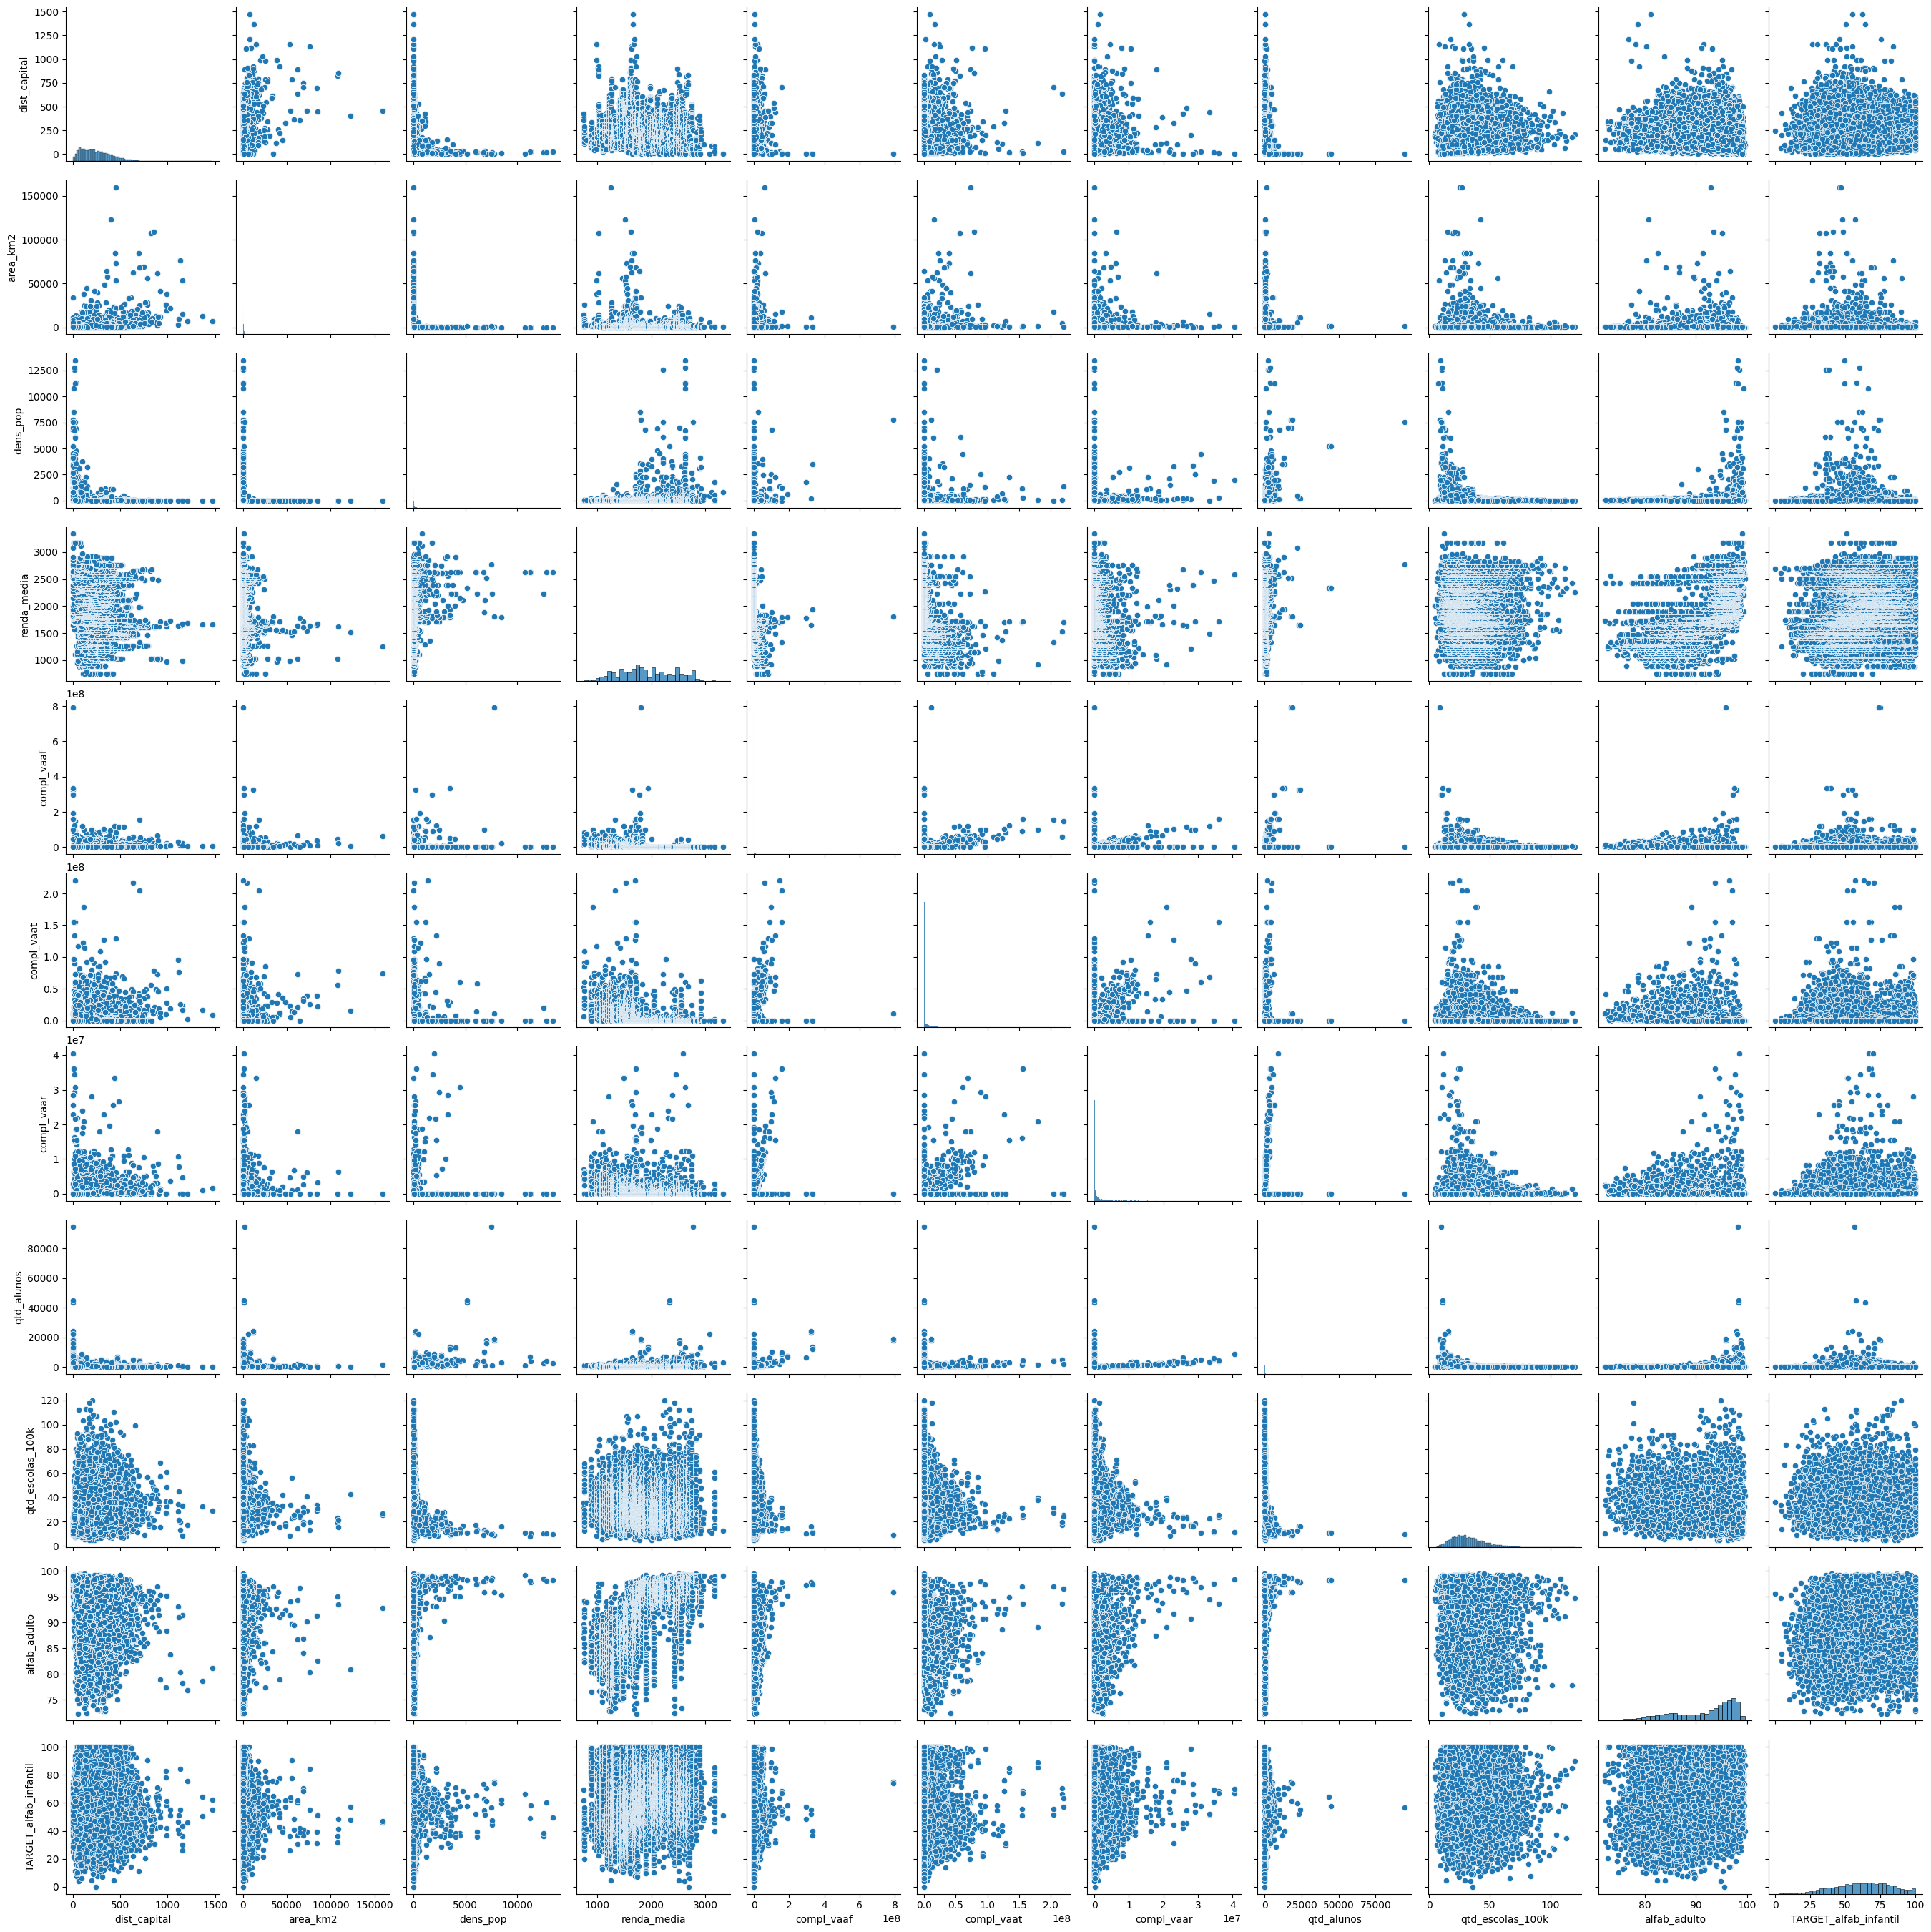

In [ ]:
import seaborn as sns

sns.pairplot(df_numeric)

Quando começamos a investigar os modelos, descobrimos que os dados de allfabetização infantil de 2023 estavam indisponíveis para os estados: Acre, Distrito Federal, Roraima e São Paulo. Decidimos imputar os dados aplicando um redutor na variável target a partir dos demais estados.

In [ ]:
-- imputando 2023 para estados q não tem

Insert into `etapa2-techchallenge.silver._silverfinal`
SELECT `id_municipio`, `nome`, `uf`, `fl_capital`, `lat`, `long`, `dist_capital`,
 `pop`, `area_km2`, `dens_pop`, `renda_media`, `fl_renda_inferida`, `receita_fundeb`,
 `compl_vaaf`, `compl_vaat`, `compl_vaar`, `desp_empenhada`, `desp_liquidada`,
 `desp_paga`,"2023" as `ano`, `qtd_escolas`, `qtd_alunos`, `qtd_escolas_100k`,
  `alfab_adulto`, `alfab_idoso`, round(`TARGET_alfab_infantil`*0.973229,2) as TARGET_alfab_infantil
FROM `etapa2-techchallenge.silver._silverfinal`
where uf in ("AC", "DF","RR","SP") and ano = "2024"
order by uf;



In [ ]:
pip install pandas numpy matplotlib scikit-learn kneed

# Criação das tabelas Gold (ML)

Aqui vamos criar as tabelas Gold para os modelos de ML.

# Incluir o debate sobre quais modelos ML usar

Cada tabela desta camada alimentará apenas um modelo (ou pequeno grupo), e apenas para treino ou para teste.

In [ ]:
Create or replace table `etapa2-techchallenge.gold._reg_arv_treino` as
SELECT
nome, fl_capital, pop, area_km2, dens_pop, dist_capital, -- dados basicos
renda_media, fl_renda_inferida,                          -- dados de renda (PIB per capita)
receita_fundeb, compl_vaaf, compl_vaat, compl_vaar,      -- dados de receita fundeb
desp_empenhada, desp_liquidada, desp_paga,               -- dados de despesas
ano, qtd_alunos, qtd_escolas_100k, qtd_escolas,          -- dados de Censo escolar
alfab_adulto, alfab_idoso, meta_alfabetizacao_2025,      -- dados de alfabetização
TARGET_alfab_infantil                                    -- variavel target
FROM `etapa2-techchallenge.silver._silverfinal` where ano = "2023";

Create or replace table `etapa2-techchallenge.gold._reg_arv_teste` as
SELECT
nome, fl_capital, pop, area_km2, dens_pop, dist_capital, -- dados basicos
renda_media, fl_renda_inferida,                          -- dados de renda (PIB per capita)
receita_fundeb, compl_vaaf, compl_vaat, compl_vaar,      -- dados de receita fundeb
desp_empenhada, desp_liquidada, desp_paga,               -- dados de despesas
ano, qtd_alunos, qtd_escolas_100k, qtd_escolas,          -- dados de Censo escolar
alfab_adulto, alfab_idoso, meta_alfabetizacao_2025,      -- dados de alfabetização
TARGET_alfab_infantil                                    -- variavel target
FROM `etapa2-techchallenge.silver._silverfinal` where ano = "2024";

Create or replace table `etapa2-techchallenge.gold._kmeans_treino` as
SELECT
nome, fl_capital, lat, long, dist_capital, pop, area_km2, dens_pop,       -- dados basicos
renda_media, fl_renda_inferida,                                           -- dados de renda (PIB per capita)
receita_fundeb, compl_vaaf, compl_vaat, compl_vaar,                       -- dados de receita fundeb
desp_empenhada, desp_liquidada, desp_paga,                                -- dados de despesas
ano, qtd_alunos, qtd_escolas_100k, qtd_escolas,                           -- dados de Censo escolar
alfab_adulto, alfab_idoso, meta_alfabetizacao_2025, TARGET_alfab_infantil -- dados de alfabetização
FROM `etapa2-techchallenge.silver._silverfinal` where ano = "2023"

# Modelo 1: Clusterização de municípios por indicadores socioeconômicos e educacionais com K-means

Como o objetivo aqui é descobrir grupos de cidades parecidas, sem rótulo prévio, o problema é não supervisionado, e por isso usamos K-Means, que é quem de fato usa "k" e "curva de cotovelo" para decidir o número de grupos.

Foram obtidos os seguintes agrupamentos:
* Grupo 5: capitais
* Grupo 4: regiões metropolitanas
* Grupo 2+3: cidades pequenas/médias do interior com renda ainda relativamente alta
* Grupo 0+1: cidades pequenas/médias do interior com renda baixa

Com isso o poder público poderá ter uma atuação organizacional mais direcionada.


Matriz preparada: 5535 cidades x 18 indicadores


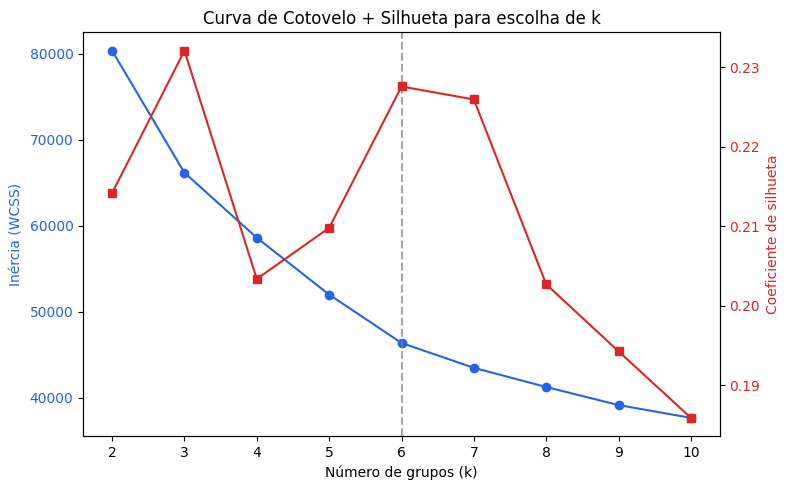

k | inércia   | silhueta
 2 |   80360.5 | 0.2142
 3 |   66176.3 | 0.2321
 4 |   58623.2 | 0.2034
 5 |   52012.9 | 0.2098
 6 |   46395.5 | 0.2276
 7 |   43502.2 | 0.2259
 8 |   41275.8 | 0.2027
 9 |   39180.1 | 0.1943
10 |   37689.6 | 0.1859

Cotovelo detectado automaticamente em k = 6
Modelo treinado com k=6. Silhueta média final: 0.2276
grupo
0     846
1    1133
2    1457
3    1359
4     714
5      26
Name: count, dtype: int64


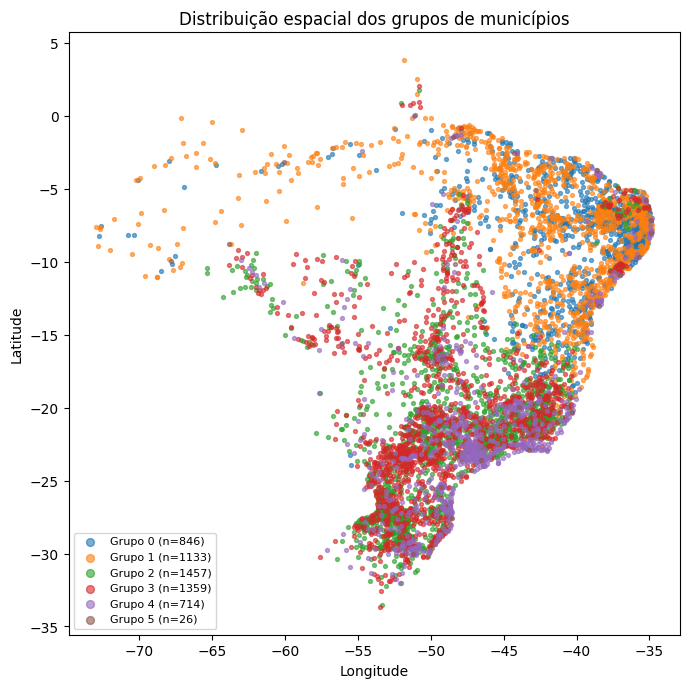


Perfil médio de cada grupo:
              pop  dens_pop  renda_media  alfab_adulto  alfab_idoso  qtd_escolas_100k  dist_capital  fl_capital
grupo                                                                                                          
0        21760.67     46.15      1459.30         85.13        47.50             35.53        257.50         0.0
1         20297.8     39.29      1468.56         85.39        47.78             35.21        268.40         0.0
2         8596.61     27.69      2200.60         95.22        76.89             34.92        273.58         0.0
3         9542.34     29.12      2206.46         94.70        74.44             34.19        273.38         0.0
4       125182.73    578.30      2214.59         97.17        84.71             22.54        162.58         0.0
5      1772013.15   2656.94      2253.55         97.18        87.18             13.57          0.00         1.0
Arquivo 'cidades_com_grupos.csv' salvo no ambiente do Colab.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# O Colab já vem com matplotlib configurado para exibir os gráficos inline;
# a linha abaixo só reforça isso.
%matplotlib inline

# A biblioteca 'kneed' geralmente não vem pré-instalada no Colab:
!pip install kneed -q
from kneed import KneeLocator

SEED = 42  # semente fixa para os resultados serem sempre reprodutíveis

query = "SELECT * FROM etapa2-techchallenge.gold._kmeans_treino"

df = client.query(query).to_dataframe()

# %%
# CÉLULA 2 — Preparação dos dados
# ---------------------------------------------------------------------------
def preparar_dados(df):
    """
    Recebe o DataFrame já carregado (`df`) e devolve a matriz de features
    padronizada, pronta para o KMeans.

    Decisões de modelagem:
      - 'nome', 'lat', 'long' e 'ano' ficam de fora das FEATURES:
            nome/lat/long são identificadores/coordenadas (usados só na
            Parte 3, para plotar o mapa, não para calcular distância);
            'ano' é constante (2023) em todo o dataset, logo não discrimina nada.
      - 'fl_renda_inferida' é uma flag de qualidade do dado (indica se a
        renda foi estimada), não um indicador socioeconômico -> descartada.
      - 'TARGET_alfab_infantil' é o alvo de um problema supervisionado à
        parte; não é usada aqui para não "vazar" a resposta para dentro
        dos próprios grupos.
      - Colunas monetárias/contagens (pop, área, receitas, despesas,
        escolas, alunos) têm distribuição muito assimétrica (poucas
        cidades enormes e milhares de cidades pequenas). Sem tratamento,
        essas variáveis dominam a distância euclidiana e o KMeans separa
        apenas "outliers" (grandes capitais) do resto. Por isso aplicamos
        log1p nelas antes de padronizar.
    """
    colunas_log = [
        "pop", "area_km2", "receita_fundeb", "compl_vaaf",
        "compl_vaat", "compl_vaar", "desp_empenhada", "desp_liquidada",
        "desp_paga", "qtd_escolas", "qtd_alunos", "qtd_escolas_100k",
        "dist_capital",
    ]
    colunas_diretas = ["fl_capital", "renda_media", "alfab_adulto", "alfab_idoso"]

    df_features = df.copy()
    for coluna in colunas_log:
        df_features[coluna] = np.log1p(df_features[coluna].clip(lower=0))

    colunas_modelo = colunas_log + colunas_diretas
    X = df_features[colunas_modelo].values

    scaler = StandardScaler()
    X_padronizado = scaler.fit_transform(X)

    return X_padronizado, colunas_modelo


X_padronizado, colunas_usadas = preparar_dados(df)
print(f"Matriz preparada: {X_padronizado.shape[0]} cidades x {X_padronizado.shape[1]} indicadores")


# %%
# CÉLULA 3 — PARTE 1: definição do k ótimo (curva de cotovelo + silhueta)
# ---------------------------------------------------------------------------
def definir_k_otimo(X_padronizado, k_min=2, k_max=10):
    """
    Testa vários valores de k e calcula, para cada um:
      - Inércia (WCSS): soma das distâncias quadráticas de cada ponto ao
        centro do seu grupo. Sempre cai quando k aumenta; o "cotovelo" é
        o ponto onde essa queda passa a ser pequena (ganho marginal baixo).
      - Silhueta média: mede o quão bem separados e coesos estão os
        grupos (varia de -1 a 1; quanto maior, melhor). Serve para
        confirmar/desempatar a leitura do cotovelo.
    """
    valores_k = list(range(k_min, k_max + 1))
    inercias, silhuetas = [], []

    for k in valores_k:
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        rotulos = kmeans.fit_predict(X_padronizado)
        inercias.append(kmeans.inertia_)
        silhuetas.append(silhouette_score(X_padronizado, rotulos))

    localizador = KneeLocator(valores_k, inercias, curve="convex", direction="decreasing")
    k_cotovelo = localizador.elbow

    fig, eixo_inercia = plt.subplots(figsize=(8, 5))
    eixo_inercia.plot(valores_k, inercias, marker="o", color="#2563eb", label="Inércia (WCSS)")
    eixo_inercia.axvline(k_cotovelo, color="gray", linestyle="--", alpha=0.7,
                          label=f"Cotovelo automático (k={k_cotovelo})")
    eixo_inercia.set_xlabel("Número de grupos (k)")
    eixo_inercia.set_ylabel("Inércia (WCSS)", color="#2563eb")
    eixo_inercia.tick_params(axis="y", labelcolor="#2563eb")

    eixo_silhueta = eixo_inercia.twinx()
    eixo_silhueta.plot(valores_k, silhuetas, marker="s", color="#dc2626", label="Silhueta média")
    eixo_silhueta.set_ylabel("Coeficiente de silhueta", color="#dc2626")
    eixo_silhueta.tick_params(axis="y", labelcolor="#dc2626")

    eixo_inercia.set_title("Curva de Cotovelo + Silhueta para escolha de k")
    fig.tight_layout()
    plt.show()  # no Colab, basta 'show' — o gráfico aparece direto na célula

    print("k | inércia   | silhueta")
    for k, inercia, silhueta in zip(valores_k, inercias, silhuetas):
        print(f"{k:2d} | {inercia:9.1f} | {silhueta:.4f}")
    print(f"\nCotovelo detectado automaticamente em k = {k_cotovelo}")

    return valores_k, inercias, silhuetas


definir_k_otimo(X_padronizado)
# -> No dataset de referência, a silhueta empata entre k=3 e k=6; k=3 é
#    escolhido na Célula 4 por gerar grupos mais equilibrados e interpretáveis.
#    Ajuste K_ESCOLHIDO abaixo se, com seus dados, outro k fizer mais sentido.


# %%
# CÉLULA 4 — PARTE 2: treinamento do modelo final
# ---------------------------------------------------------------------------
K_ESCOLHIDO = 6  # <-- ajuste aqui, com base no gráfico da Célula 3

def treinar_modelo_final(df, X_padronizado, k_escolhido):
    """
    Treina o KMeans definitivo e devolve o DataFrame original com uma nova
    coluna 'grupo' (0, 1, 2, ...), reordenada por renda média crescente
    para facilitar a leitura ("do mais vulnerável ao mais próspero").
    """
    kmeans_final = KMeans(n_clusters=k_escolhido, random_state=SEED, n_init=10)
    rotulos_brutos = kmeans_final.fit_predict(X_padronizado)

    df_resultado = df.copy()
    df_resultado["grupo_bruto"] = rotulos_brutos

    ordem_por_renda = (
        df_resultado.groupby("grupo_bruto")["renda_media"].mean()
        .sort_values().index.tolist()
    )
    mapa_reordenacao = {antigo: novo for novo, antigo in enumerate(ordem_por_renda)}
    df_resultado["grupo"] = df_resultado["grupo_bruto"].map(mapa_reordenacao)
    df_resultado = df_resultado.drop(columns=["grupo_bruto"])

    silhueta_final = silhouette_score(X_padronizado, rotulos_brutos)
    print(f"Modelo treinado com k={k_escolhido}. Silhueta média final: {silhueta_final:.4f}")
    print(df_resultado["grupo"].value_counts().sort_index())

    return df_resultado, kmeans_final


df_com_grupos, modelo_kmeans = treinar_modelo_final(df, X_padronizado, K_ESCOLHIDO)
df_com_grupos.head()


# %%
# CÉLULA 5 — PARTE 3: gráfico de região e perfil dos grupos
# ---------------------------------------------------------------------------
def visualizar_grupos_no_mapa(df_resultado):
    """
    Plota cada cidade em um "mapa" (longitude x latitude), colorida pelo
    grupo ao qual pertence, e imprime a média das principais variáveis por
    grupo para orientar a interpretação de cada um.
    """
    paleta = plt.cm.tab10.colors  # paleta genérica, funciona para qualquer k

    fig, eixo = plt.subplots(figsize=(7, 8))
    for i, grupo in enumerate(sorted(df_resultado["grupo"].unique())):
        subconjunto = df_resultado[df_resultado["grupo"] == grupo]
        eixo.scatter(
            subconjunto["long"], subconjunto["lat"],
            s=8, alpha=0.6, color=paleta[i % len(paleta)],
            label=f"Grupo {grupo} (n={len(subconjunto)})",
        )
    eixo.set_xlabel("Longitude")
    eixo.set_ylabel("Latitude")
    eixo.set_title("Distribuição espacial dos grupos de municípios")
    eixo.set_aspect("equal")
    eixo.legend(loc="lower left", fontsize=8, markerscale=2)
    fig.tight_layout()
    plt.show()

    colunas_perfil = [
        "pop", "dens_pop", "renda_media", "alfab_adulto", "alfab_idoso",
        "qtd_escolas_100k", "dist_capital", "fl_capital",
    ]
    perfil = df_resultado.groupby("grupo")[colunas_perfil].mean().round(2)
    print("\nPerfil médio de cada grupo:")
    print(perfil.to_string())

    return perfil


perfil_grupos = visualizar_grupos_no_mapa(df_com_grupos)

# Comentário sobre os grupos (referência obtida com o dataset original,
# k=3): grupo de renda/alfabetização mais baixas concentrado no
# Norte/Nordeste; grupo de polos urbanos com maior população e renda,
# espalhado pelo país; grupo de pequenos municípios com renda e
# alfabetização altas, concentrado no Sul/Sudeste. Com outro `df`, releia
# o `perfil_grupos` acima para atualizar essa leitura.


# %%
# CÉLULA 6 (opcional) — exportar o resultado
# ---------------------------------------------------------------------------
# No Colab, isso salva o arquivo no ambiente de execução (não no seu PC).
# Para baixar, use: from google.colab import files; files.download('cidades_com_grupos.csv')

df_com_grupos.to_csv("cidades_com_grupos.csv", index=False)
print("Arquivo 'cidades_com_grupos.csv' salvo no ambiente do Colab.")

# Modelo 2: Ranqueamento das variáveis independentes com Random Forest

Aqui a ideia é identificar as variáveis com maior influência na varivável target (alfabetização infantil)

Concluímos que as principais variáveis que afetam o analfabetismo são estruturais: alfabetização dos adultos (proxy para ambientes em que os pais são letrados e incentivam a educação dos filhos) e renda média (proxy geral para acesso a tudo, inclusive educação). O maior fator encontrado que tem alguma atuação pelo poder público é a **Receita Fundeb** (repasses aos municípios), levando a achar que o financiamento público é o maior fator na luta contra o analfabetismo.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import os

RANDOM_STATE = 42

# -----------------------------------------------------------------------------
# 1.1 — Carregamento e preparação dos dados
# -----------------------------------------------------------------------------
# O CSV contém 1 linha por município (ano fixo = 2023). Removemos identificadores
# (nome do município) e colunas constantes (ano), que não têm poder preditivo.

query = "SELECT * FROM etapa2-techchallenge.gold._reg_arv_treino"

df = client.query(query).to_dataframe()

columns_to_drop = ['desp_empenhada', 'desp_liquidada', 'desp_paga', # muitos zeros
                   'id_municipio', 'fl_renda_inferida', 'fl_capital', # IDs/flags
                   'qtd_escolas', 'pop',      # tirando refs diretas à população
                   'alfab_idoso',             # alta correlação com alfab adulto
                   'lat', 'long',             # variaveis geograficas
                   ]

df = df.drop(columns=columns_to_drop, errors='ignore')

ID_COLS = ["nome", "ano"]
TARGET = "meta_alfabetizacao_2025"

# alfab_idoso é mantida como preditora: é um indicador correlato (não o alvo),
# refletindo condições históricas/estruturais de educação do município.
FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Impute NaN values in the target variable y
if y.isnull().any():
    median_y = y.median()
    y = y.fillna(median_y)

print("Dimensão do dataset:", df.shape)
print("Variáveis preditoras utilizadas:", FEATURES)

# -----------------------------------------------------------------------------
# 1.2 — Divisão treino/teste
# -----------------------------------------------------------------------------
# 80% treino / 20% teste, com semente fixa para reprodutibilidade.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# -----------------------------------------------------------------------------
# 1.3 — Treinamento do modelo Random Forest Regressor
# -----------------------------------------------------------------------------
# n_estimators=400: número de árvores suficiente para estabilizar a importância
# das variáveis sem custo computacional excessivo.
# max_depth=None: árvores podem crescer até a folha pura, controlado por
# min_samples_leaf para evitar overfitting.
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

# -----------------------------------------------------------------------------
# 1.4 — Avaliação do modelo
# -----------------------------------------------------------------------------
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Validação cruzada (5 folds) para checar estabilidade do desempenho
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")

print("\n--- Desempenho do Random Forest (holdout 20%) ---")
print(f"MAE  (erro médio absoluto): {mae:.3f} pontos percentuais")
print(f"R²   (holdout):             {r2:.3f}")
print(f"R²   (média CV 5-fold):     {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# -----------------------------------------------------------------------------
# 1.5 — Importância das variáveis (Feature Importance)
# -----------------------------------------------------------------------------
importances = pd.DataFrame({
    "variavel": FEATURES,
    "importancia": rf_model.feature_importances_
}).sort_values("importancia", ascending=False).reset_index(drop=True)

print("\n--- Ranking de importância das variáveis (Random Forest) ---")
print(importances.to_string(index=False))

# Salvamos os artefatos para uso nas Partes 2 e 3
importances.to_csv("outputs_rf_feature_importance.csv", index=False)
joblib.dump(rf_model, "outputs_rf_model.joblib")

metrics_rf = pd.DataFrame([
{
    "modelo": "RandomForestRegressor",
    "MAE": mae,
    "R2_holdout": r2,
    "R2_cv_mean": cv_scores.mean(),
    "R2_cv_std": cv_scores.std(),
}
])
metrics_rf.to_csv("outputs_rf_metrics.csv", index=False)

print("\nOutputs salvos: rf_feature_importance.csv, rf_model.joblib, rf_metrics.csv")

Dimensão do dataset: (4871, 14)
Variáveis preditoras utilizadas: ['dist_capital', 'area_km2', 'dens_pop', 'renda_media', 'receita_fundeb', 'compl_vaaf', 'compl_vaat', 'compl_vaar', 'qtd_alunos', 'qtd_escolas_100k', 'alfab_adulto']

--- Desempenho do Random Forest (holdout 20%) ---
MAE  (erro médio absoluto): 8.195 pontos percentuais
R²   (holdout):             0.349
R²   (média CV 5-fold):     0.271 (+/- 0.066)

--- Ranking de importância das variáveis (Random Forest) ---
        variavel  importancia
    alfab_adulto     0.187883
     renda_media     0.164224
    dist_capital     0.083247
  receita_fundeb     0.082564
        dens_pop     0.079159
        area_km2     0.079070
      compl_vaaf     0.074426
      compl_vaat     0.068345
qtd_escolas_100k     0.067898
      qtd_alunos     0.066978
      compl_vaar     0.046206

Artefatos salvos em outputs/: rf_feature_importance.csv, rf_model.joblib, rf_metrics.csv


# MODELO 3: Inferindo probabilidade de atingimento de metas com Regressão Logística

Esta análise foi feita em duas etapas:
* primeiro olhamos de forma binária se o município bateu ou não as metas, e o modelo, a partir de um treino com as variáveis de 2023 e o batimento de metas, predisse com base nas variáveis de 2024 se o município iria bater as metas de 2025.
* depois o modelo calculou a probabilidade de batimento da meta, num intervalo dew 0% a 100%, para permitir o rankeamento de municípios desde a maior probabilidade (incluindo municípios que já bateram a meta) até municípios com a probabilidade perto de zero, seja porque estão muito distantes da meta, ou porque as variáveis socioeconômicas explicativas que trouxemos para a análise estão em níveis ruins.

Conclusões:
* Fundeb teve o maior impacto, mas com coeficiente negativo, resultado  contraintuitivo para nós.
* Retomamos a EDA comparando financiamento Fundeb e atingimento das metas entre 2023 (treino) e 2024 (teste).
* Alta variabilidade nas duas variáveis, resultando em uma correlação muito baixa entre financiamento e atingimento da meta.
* Concluímos que são necessárias mais variáveis, incluindo aplicação do financiamento, e fatores socioeconômicos como infraestrutura, ensino, criminalidade e insegurança alimentar.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import joblib

RANDOM_STATE = 42

# -----------------------------------------------------------------------------
# 2.1 — Carregamento e engenharia do alvo binário
# -----------------------------------------------------------------------------
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery

client = bigquery.Client(project="etapa2-techchallenge")

query = "SELECT * FROM etapa2-techchallenge.gold._reg_arv_treino" # dados 2023

df = client.query(query).to_dataframe()

ID_COLS = ["nome", "ano"]

# META_VALOR = df[TARGET_CONTINUOUS].quantile(META_PERCENTIL)
df["bate_meta_infantil"] = (df["TARGET_alfab_infantil"] >= df["meta_alfabetizacao_2025"]).astype(int)

# --- Feature Engineering: Criação das novas variáveis solicitadas pelo usuário ---
df["Compl_Total"] = df["compl_vaaf"] + df["compl_vaat"] + df["compl_vaar"]

# Certifica-se de lidar com divisão por zero em qtd_alunos, substituindo por NaN ou 0 antes da divisão
# e depois imputando esses NaNs no pipeline de imputação.
df["financ_por_aluno"] = (df["receita_fundeb"] + df["Compl_Total"]) / df["qtd_alunos"]
# Para evitar NaNs infinitos se qtd_alunos for zero, podemos usar np.where
df["financ_por_aluno"] = np.where(df["qtd_alunos"] == 0, np.nan, (df["receita_fundeb"] + df["Compl_Total"]) / df["qtd_alunos"])

# Define columns to drop for Logistic Regression (similar to Random Forest)
columns_to_drop = [
    'desp_empenhada', 'desp_paga', # muitos zeros
    'id_municipio', 'fl_renda_inferida', 'fl_capital', # IDs/flags
    'qtd_escolas', 'pop', 'qtd_alunos' # valores absolutos
    # 'alfab_idoso',             # alta correlação com alfab adulto
    'ano', # 'ano' is constant (2023) in this dataset, thus not discriminative.
    # Se Compl_Total for usada, as variáveis individuais de complementação podem ser descartadas para evitar multicolinearidade
    'compl_vaaf', 'compl_vaat', 'compl_vaar' # contemplados na variavel de total
]

# Drop columns from the main dataframe before defining FEATURES
df_filtered = df.drop(columns=columns_to_drop, errors='ignore')

FEATURES = [c for c in df_filtered.columns
            if c not in ID_COLS + ["TARGET_alfab_infantil", "meta_alfabetizacao_2025", "bate_meta_infantil"] ]
print("Variáveis preditoras utilizadas:", FEATURES)
print("Variáveis preditoras não utilizadas:", [x for x in df.columns if x not in FEATURES])

X = df_filtered[FEATURES].copy()
y = df_filtered["bate_meta_infantil"].copy()

# Impute remaining NaN values in X with the median of their respective columns
for column in X.columns:
    if X[column].isnull().any():
        median_val = X[column].median()
        X[column] = X[column].fillna(median_val)

print(f"Meta adotada: metas municipais individuais")
print("Distribuição da classe-alvo (bate_meta_infantil):")
print(y.value_counts(normalize=True).rename("proporcao"))

# -----------------------------------------------------------------------------
# 2.2 — Divisão treino/teste (estratificada)
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# -----------------------------------------------------------------------------
# 2.3 — Padronização das variáveis
# -----------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------------------------------------------------------
# 2.4 — Treinamento do modelo de Regressão Logística
# -----------------------------------------------------------------------------
logreg_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
logreg_model.fit(X_train_scaled, y_train)


# -----------------------------------------------------------------------------
# 2.5 — Avaliação do modelo
# -----------------------------------------------------------------------------
query_eval = "SELECT * FROM etapa2-techchallenge.gold._reg_arv_teste"
df_eval = client.query(query_eval).to_dataframe()

# Impute NaN values in TARGET_CONTINUOUS of df_eval with the median from the training data.
# This ensures consistency and explicit handling for evaluation.
median_target_continuous_train = df["TARGET_alfab_infantil"].median()
df_eval["TARGET_alfab_infantil"] = df_eval["TARGET_alfab_infantil"].fillna(median_target_continuous_train)

# --- Feature Engineering: Criação das novas variáveis para o df_eval ---
df_eval["Compl_Total"] = df_eval["compl_vaaf"] + df_eval["compl_vaat"] + df_eval["compl_vaar"]
df_eval["financ_por_aluno"] = np.where(df_eval["qtd_alunos"] == 0, np.nan, (df_eval["receita_fundeb"] + df_eval["Compl_Total"]) / df_eval["qtd_alunos"])

# Create the binary target for the test DataFrame, using metas individuais de município
df_eval_target = (df_eval["TARGET_alfab_infantil"] >= df_eval["meta_alfabetizacao_2025"]).astype(int)

# Apply the same column dropping as done for the training data
df_eval_filtered = df_eval.drop(columns=columns_to_drop, errors='ignore')

# Select the same features as used for training
X_eval_data = df_eval_filtered[FEATURES].copy()

# Impute NaN values in X_eval_data using the medians calculated from the training X
# This is crucial to prevent data leakage from the test set.
for column in X_eval_data.columns:
    if X_eval_data[column].isnull().any():
        median_val_from_train = X[column].median() # X is the full training feature set
        X_eval_data[column] = X_eval_data[column].fillna(median_val_from_train)

# Scale the test features using the *fitted* scaler from training
X_eval_data_scaled = scaler.transform(X_eval_data)

# Now evaluate using the new test data
y_pred = logreg_model.predict(X_eval_data_scaled)
y_proba = logreg_model.predict_proba(X_eval_data_scaled)[:, 1]

# Assign df_teste_target to y_test for metrics calculation to ensure consistency in print statements
# df_eval_target: bateu meta realizado de 24
# y_pred:         bateu meta previsto com dados de 24 conforme meta 25
y_test = df_eval_target

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("\n--- Desempenho da Regressão Logística (df_teste) ---")
print(f"Acurácia:  {acc:.3f}")
print(f"Precisão:  {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")
print("\nMatriz de confusão (linhas=real, colunas=predito):")
cm2 = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
print(cm2)

print("\nRelatório de classificação completo:")
print(classification_report(y_test, y_pred, target_names=["Nao_bate_meta", "Bate_meta"]))

# -----------------------------------------------------------------------------
# 2.6 — Coeficientes do modelo (impacto de cada variável na probabilidade)
# -----------------------------------------------------------------------------
coef_df = pd.DataFrame({
    "variavel": FEATURES,
    "coeficiente": logreg_model.coef_[0],
}).sort_values("coeficiente", key=abs, ascending=False).reset_index(drop=True)

coef_df["odds_ratio"] = np.exp(coef_df["coeficiente"])

print("\n--- Coeficientes da Regressão Logística (ranking por impacto absoluto) ---")
print(coef_df.to_string(index=False))

# -----------------------------------------------------------------------------
# 2.7 — Predição para todos os municípios (probabilidade de bater a meta)
# -----------------------------------------------------------------------------
# Use df_teste for full prediction and ranking
df_all_pred = df_eval.copy()
df_all_pred_filtered = df_all_pred.drop(columns=columns_to_drop, errors='ignore')

# *** ADDED: Create 'bate_meta_infantil' column for df_all_pred ***
df_all_pred["bate_meta_infantil"] = (df_all_pred["TARGET_alfab_infantil"] >= df_all_pred["meta_alfabetizacao_2025"])

# Select the same features as used for training
X_all_data = df_all_pred_filtered[FEATURES].copy()

# Impute NaN values in X_all_data using the medians calculated from the training X
for column in X_all_data.columns:
    if X_all_data[column].isnull().any():
        median_val_from_train = X[column].median()
        X_all_data[column] = X_all_data[column].fillna(median_val_from_train)

X_all_scaled = scaler.transform(X_all_data)

df_all_pred["prob_bate_meta_infantil"] = logreg_model.predict_proba(X_all_scaled)[:, 1]
df_all_pred["predicao_bate_meta_infantil"] = logreg_model.predict(X_all_scaled)

# # Lógica adicionada: Se a meta já foi batida, a probabilidade é 1
# already_met_goal_condition = df_all_pred["TARGET_alfab_infantil"] >= META_VALOR
# df_all_pred.loc[already_met_goal_condition, "prob_bate_meta_infantil"] = 1.0
# df_all_pred.loc[already_met_goal_condition, "predicao_bate_meta_infantil"] = 1

ranking_municipios = df_all_pred[["nome", "TARGET_alfab_infantil", "meta_alfabetizacao_2025", # "bate_meta_infantil",
                          "prob_bate_meta_infantil", "predicao_bate_meta_infantil"]] \
    .sort_values("prob_bate_meta_infantil", ascending=False)

# Round the probability to 2 decimal places
ranking_municipios["prob_bate_meta_infantil"] = ranking_municipios["prob_bate_meta_infantil"].round(2)
print("Variáveis preditoras utilizadas:", FEATURES)
print("Variáveis preditoras não utilizadas:", [x for x in df.columns if x not in FEATURES])

print("\n--- Top 10 municípios com maior probabilidade de bater a meta infantil (df_teste) ---")
print(ranking_municipios.head(10).to_string(index=False))

print("\n--- Top 10 municípios com MENOR probabilidade de bater a meta infantil (df_teste) ---")
print(ranking_municipios.tail(10).to_string(index=False))

# -----------------------------------------------------------------------------
# 2.8 — Persistência de artefatos
# -----------------------------------------------------------------------------
coef_df.to_csv("outputs_logreg_coeficientes.csv", index=False)
ranking_municipios.to_csv("outputs_logreg_ranking_municipios.csv", index=False)
joblib.dump({"model": logreg_model, "scaler": scaler, "features": FEATURES}, "outputs_logreg_model.joblib")

metrics_logreg = pd.DataFrame([{ "modelo": "LogisticRegression",
    "target": "bate_meta_infantil",
    "acuracia": acc,
    "precisao": prec,
    "recall": rec,
    "f1": f1,
    "roc_auc": auc,
}])
metrics_logreg.to_csv("outputs_logreg_metrics.csv", index=False)

print("\nOutputs salvos: outputs_logreg_coeficientes.csv, outputs_logreg_ranking_municipios.csv, "
      "logreg_model.joblib, logreg_metrics.csv")

Variáveis preditoras utilizadas: ['area_km2', 'dens_pop', 'dist_capital', 'renda_media', 'receita_fundeb', 'desp_liquidada', 'qtd_alunos', 'qtd_escolas_100k', 'alfab_adulto', 'alfab_idoso', 'Compl_Total', 'financ_por_aluno']
Variáveis preditoras não utilizadas: ['nome', 'fl_capital', 'pop', 'fl_renda_inferida', 'compl_vaaf', 'compl_vaat', 'compl_vaar', 'desp_empenhada', 'desp_paga', 'ano', 'qtd_escolas', 'meta_alfabetizacao_2025', 'TARGET_alfab_infantil', 'bate_meta_infantil']
Meta adotada: metas municipais individuais
Distribuição da classe-alvo (bate_meta_infantil):
bate_meta_infantil
0    0.772737
1    0.227263
Name: proporcao, dtype: float64

--- Desempenho da Regressão Logística (df_teste) ---
Acurácia:  0.549
Precisão:  0.481
Recall:    0.519
F1-score:  0.499
ROC-AUC:   0.553

Matriz de confusão (linhas=real, colunas=predito):
Predicted     0     1
Actual               
0          1791  1339
1          1147  1240

Relatório de classificação completo:
               precision    r

CONCLUSÕES:

* A variável com maior coeficiente absoluto de impacto, ou seja, com maior peso no cálculo da probabilidade de bater a meta, foi o financiamento Fundeb. Porém o coeficiente ficou negativo, refletindo muitos casos de cidades com índice de analfabetismo mais baixo mas com financiamento Fundeb mais alto.
* Percebemos que, entre os dados treino (2023) e teste (2024 -- únicos anos que tivemos disponíveis), houve grande variabilidade tanto nos financiamentos Fundeb dos municípios como nos atingimentos de meta de alfabetização. Municípios podem bater as metas num ano e não no outro, como também podem ter grandes aumentos ou grandes reduções de financiamento. Ou seja, a correlação entre as duas variáveis é muito baixa.
* Esse resultado demonstra um forte indicio de que aumentar a verba de financiamento atribuida as cidades não necessariamente implica em aumento nas taxas de alfabetização. Cidades com perfis semelhantes, recebendo verbas parecidas, podem acabar tendo resultados bastante diferentes de um ano para outro.
* Esta conclusão nos leva a crer que é necessário, para além de financiar corretamente as cidades, um modelo de governância e transparência referente as despesas empenhadas em cada munícipio. Também é interessante propor dinamismo em metas para cada municipio a depender de sua verba: municipios que receberem mais tem que, apresentar mais despesas empenhadas, e por consequência, atingir metas maiores do que municipios menores, centralizando essas observações e indicadores nos governos estaduais.
* Também é interressante utilizar como estudo de caso municipios com verbas pequenas com resultados expressivos, de forma a criar um plano educacional mais eficiente. Os modelos permitem direcionar essas políticas públicas de incentivo, como criação de escolas, diretorias de ensino e orgãos de fomento em regiões com alta densidade ou necessidade populacional.


# Explorações futuras

* Para investigações futuras, serão necessárias mais variáveis para explicar essa correlação, talvez aprofundando no detalhamento de como esse dinheiro é gasto: salários de professores, contratação de novos, infra-estrutura, abertura de novas escolas, modelo de ensino, material didático, merenda infantil etc. E também outras variáveis socioeconômicas que possam influenciar na alfabetização, como criminalidade, violência doméstica, e até mesmo insegurança econômica e/ou alimentar.

# EDA (Exploratory Data Analysis)

Comaçamos com uma correlação entre as variáveis de Atingimento de Meta (Alfabetização no ano vs Meta 2025) e o financiamento Fundeb.

Percebemos que, em ambos os anos, a correlação entre essas duas variáveis é muito baixa. Temos exemplos como:

| Cidade | Fundeb / aluno '23 | Meta '23 | Alfabetizou | Gap (pp) |
| :---: | :---: | :---: | :---: | :---: |
| Coruripe/AL<br>(50k habitantes) | 111k | 80% | 94% | +14 |
| Januária/MG<br>(65k) | 60k | 35% | 40%| +5|
| Serrinha/BA<br>(80k) | 185k | 41% | 26% | -15 |
| Maceió/AL<br>(957k) | 57k | 52% | 39% | -13 |

| 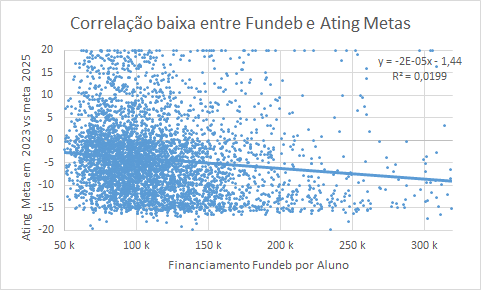 | 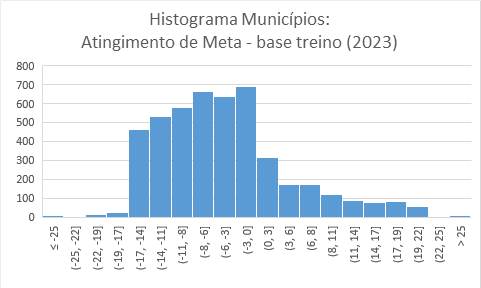 |  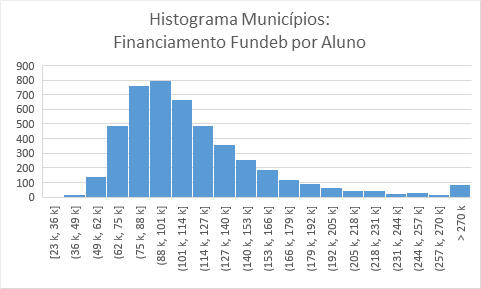 |

E na comparação 2023 e 2024, vimos que a variabilidade é enorme, tanto no financiamento Fundeb (municípios podem ter seu financiamento muito aumentado ou reduzido de um ano para outro) como no Atingimento de Metas de Alfabetização (um município que ficou muito acima da meta em 2023 pode ficar muito abaixo em 2024), como podemos ver nesta outra correlação:

| Cidade | Fundeb/aluno | Ating. Meta '23 | Ating. Meta '24
| :---: | :---: | :---: | :---: |
| Coronel Fabriciano/MG<br>(104k habitantes) | +21%<br>(de 131k para 159k) | -10pp | +6pp |
| São Borja/RS<br>(59k) | +23%<br>(de 87k para 107k) | -6pp | -23pp |
| Breves/PA<br>(107k) | -19%<br>(de 211k para 172k) | -11pp | +1pp |
| Iranduba/AM<br>(61k) | -18%<br>(de 103k para 84k) | -11pp | -19pp |


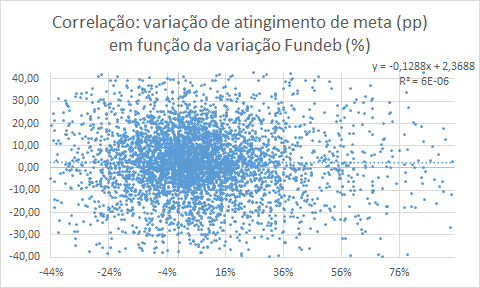

Como a própria variável dependente tem grande variabilidade, e todas as demais variáveis são fixas (dados geográficos ou macroeconômicos, que variam muito lentamente), e a única variável acionável pelo poder público também tem grande variabilidade, é esperado que ela tenha maior impacto na alfabetização e atingimento de metas, como vimos na Regressão Logística.